Prompt for Github Copilot Agent: create a whole analyses of the data, statistical description and visualization

In [25]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")

In [49]:
%matplotlib inline

# 1) Load and inspect the dataset

This notebook performs a complete descriptive analysis of the tutorial dataset, including:
- data quality checks,
- statistical summaries,
- class-wise comparisons,
- and visual exploration of key features.

In [50]:
data = pd.read_csv('../../data/tutorial_data.txt', sep=' ')

print(f"Rows: {data.shape[0]:,}")
print(f"Columns: {data.shape[1]}")
print("\nColumn names:")
print(data.columns.tolist())

data.head()

Rows: 10,000
Columns: 21

Column names:
['FIELD', 'ID', 'RA', 'Dec', 'FWHM', 'A', 'B', 'KrRadDet', 'uJAVA_auto', 'F378_auto', 'F395_auto', 'F410_auto', 'F430_auto', 'g_auto', 'F515_auto', 'r_auto', 'F660_auto', 'i_auto', 'F861_auto', 'z_auto', 'class']


,FIELD,ID,RA,Dec,FWHM,A,B,KrRadDet,uJAVA_auto,F378_auto,...,F410_auto,F430_auto,g_auto,F515_auto,r_auto,F660_auto,i_auto,F861_auto,z_auto,class
0,STRIPE82-0125,SPLUS.STRIPE82-0125.12220.griz,327.0204,-1.0042,2.64,3.08,2.40,1.39,19.89,19.78,...,19.40,18.96,18.60,18.23,17.80,17.65,17.36,17.23,17.16,GALAXY
1,STRIPE82-0130,SPLUS.STRIPE82-0130.19857.griz,329.8803,1.2223,2.19,4.50,4.30,1.31,18.66,18.56,...,17.96,17.86,17.40,17.14,16.73,16.69,16.43,16.38,16.20,GALAXY
2,STRIPE82-0051,SPLUS.STRIPE82-0051.30304.griz,35.6271,0.0222,2.13,2.79,2.70,1.74,20.56,20.64,...,20.71,20.39,20.10,19.68,19.21,19.06,18.81,18.51,18.62,GALAXY
3,STRIPE82-0032,SPLUS.STRIPE82-0032.20205.griz,21.8005,1.1796,2.33,4.29,2.48,1.48,20.59,20.81,...,19.75,19.66,18.86,18.57,18.03,17.88,17.59,17.30,17.32,GALAXY
4,STRIPE82-0003,SPLUS.STRIPE82-0003.17514.griz,0.7698,-0.0778,1.96,2.58,2.52,1.42,20.95,20.39,...,20.07,20.27,19.64,19.43,18.99,18.90,18.66,18.79,18.57,GALAXY


# 2) Data quality checks

In [51]:
missing_counts = data.isna().sum().sort_values(ascending=False)
duplicates = data.duplicated().sum()

summary_quality = pd.DataFrame({
    "missing_values": missing_counts,
    "missing_pct": (missing_counts / len(data) * 100).round(2)
})

print(f"Duplicate rows: {duplicates}")
summary_quality.head(10)

Duplicate rows: 0


,missing_values,missing_pct
FIELD,0,0.0
F410_auto,0,0.0
z_auto,0,0.0
F861_auto,0,0.0
i_auto,0,0.0
F660_auto,0,0.0
r_auto,0,0.0
F515_auto,0,0.0
g_auto,0,0.0
F430_auto,0,0.0


In [52]:
class_count = data["class"].value_counts()
class_pct = data["class"].value_counts(normalize=True).mul(100).round(2)

pd.DataFrame({
    "count": class_count,
    "percentage": class_pct
})

,count,percentage
class,,
GALAXY,5000,50.0
STAR,5000,50.0


In [30]:
numeric_cols = data.select_dtypes(include="number").columns.tolist()
print(f"Number of numeric columns: {len(numeric_cols)}")

data[numeric_cols].describe().T

Number of numeric columns: 18


,count,mean,std,min,25%,50%,75%,max
RA,10000.0,129.719136,145.851241,0.0007,18.907500,41.67355,323.5526,359.9839
Dec,10000.0,0.010390,0.710612,-1.2295,-0.600375,0.00685,0.6217,1.2599
FWHM,10000.0,2.061588,1.496810,0.7800,1.000000,1.38000,2.7800,18.6000
A,10000.0,3.217486,1.478986,1.4400,2.190000,2.70000,3.9000,25.5700
B,10000.0,2.519372,0.755782,1.3600,2.020000,2.34000,2.8100,10.2700
KrRadDet,10000.0,1.256825,0.211298,1.0000,1.060000,1.24000,1.4200,2.4300
uJAVA_auto,10000.0,19.871637,1.081690,15.7500,19.230000,20.00000,20.6300,22.6500
F378_auto,10000.0,19.629044,1.095591,15.2400,18.980000,19.78000,20.4000,22.7300
F395_auto,10000.0,19.429581,1.064838,14.7200,18.810000,19.60000,20.1900,21.9800
F410_auto,10000.0,19.020656,1.108691,14.5200,18.350000,19.22000,19.8400,21.8400


In [40]:
# Class-wise descriptive statistics for key structural features
key_features = ["FWHM", "A", "B", "KrRadDet"]

class_stats = data.groupby("class")[key_features].agg(["mean", "median", "std", "min", "max"])
class_stats

FWHM                                       A                   \
            mean median       std   min    max      mean median       std   
class                                                                       
GALAXY  3.096326   2.77  1.516924  1.03  18.60  4.204862    3.9  1.519897   
STAR    1.026850   1.00  0.196149  0.78   7.47  2.230110    2.2  0.339022   

                            B                                KrRadDet         \
         min    max      mean median       std   min    max      mean median   
class                                                                          
GALAXY  1.66  25.57  2.939528   2.77  0.829550  1.44  10.27  1.430468   1.42   
STAR    1.44   5.89  2.099216   2.07  0.318185  1.36   3.78  1.083182   1.06   

                             
             std  min   max  
class                        
GALAXY  0.143312  1.0  2.43  
STAR    0.091916  1.0  1.84

In [41]:
# Additional distribution summary with quantiles for selected variables
selected = ["FWHM", "A", "B", "KrRadDet", "g_auto", "r_auto", "i_auto", "z_auto"]

data[selected].quantile([0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99]).T

,0.01,0.05,0.25,0.50,0.75,0.95,0.99
FWHM,0.8900,0.9400,1.00,1.38,2.78,5.0000,7.1001
A,1.6500,1.8100,2.19,2.70,3.90,5.8905,8.1100
B,1.5599,1.7000,2.02,2.34,2.81,3.9900,5.1800
KrRadDet,1.0000,1.0000,1.06,1.24,1.42,1.6100,1.7801
g_auto,15.7500,16.3595,17.73,18.50,19.08,19.7700,20.1900
r_auto,15.1600,15.7500,17.02,17.78,18.39,19.1205,19.5400
i_auto,14.9400,15.4700,16.68,17.46,18.06,18.8100,19.2600
z_auto,14.7700,15.3400,16.55,17.31,17.93,18.6900,19.1601


In [42]:
# Simple standardized mean-difference ranking between classes (effect-size style)
def standardized_mean_diff(df, feature, target="class", positive_class="STAR"):
    grp1 = df.loc[df[target] == positive_class, feature]
    grp0 = df.loc[df[target] != positive_class, feature]
    pooled_std = np.sqrt((grp1.var(ddof=1) + grp0.var(ddof=1)) / 2)
    if pooled_std == 0 or np.isnan(pooled_std):
        return np.nan
    return (grp1.mean() - grp0.mean()) / pooled_std

smd = pd.Series({col: standardized_mean_diff(data, col) for col in numeric_cols}).sort_values(key=np.abs, ascending=False)
smd.head(10).to_frame("std_mean_diff(STAR - GALAXY)")

,std_mean_diff(STAR - GALAXY)
KrRadDet,-2.884712
FWHM,-1.913422
A,-1.793368
B,-1.337545
r_auto,-1.219726
F660_auto,-1.191965
i_auto,-1.149012
g_auto,-1.122688
F861_auto,-1.051492
z_auto,-1.035061


# 3) Visual analysis

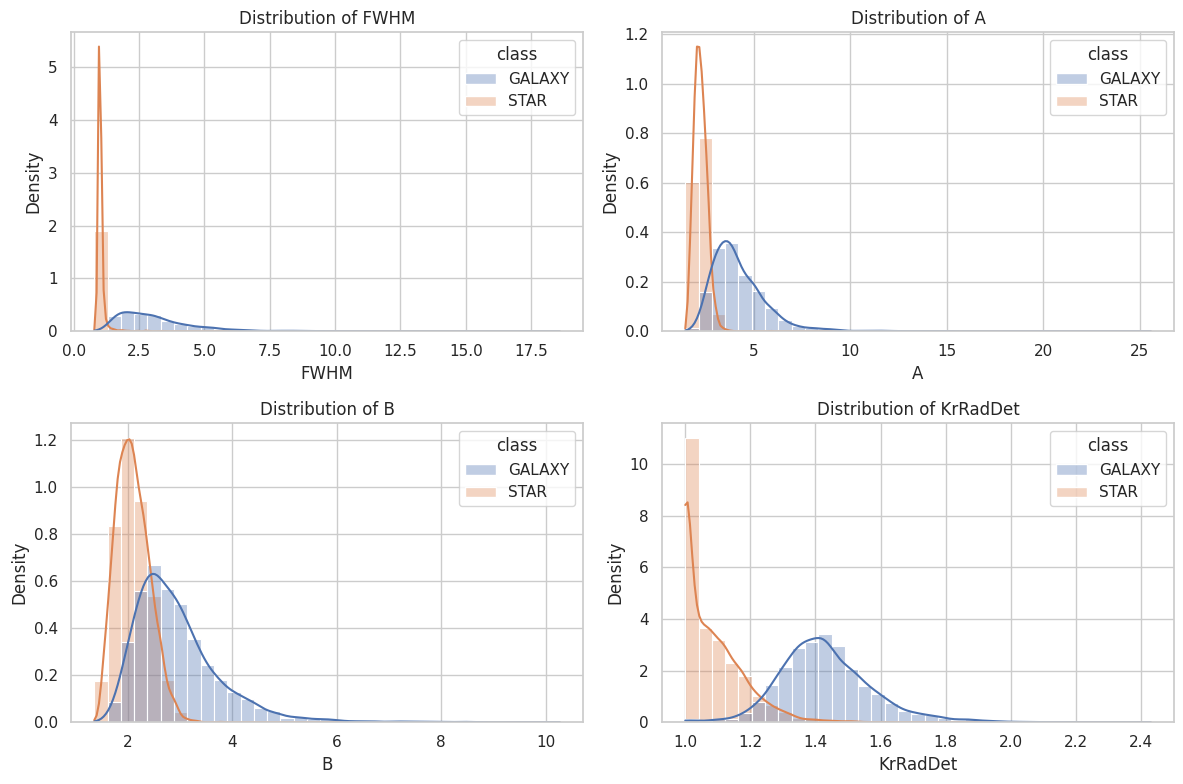

In [43]:
features_hist = ["FWHM", "A", "B", "KrRadDet"]
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for ax, feature in zip(axes.flatten(), features_hist):
    sns.histplot(data=data, x=feature, hue="class", bins=35, kde=True, stat="density", common_norm=False, ax=ax, alpha=0.35)
    ax.set_title(f"Distribution of {feature}")

plt.tight_layout()
plt.show()

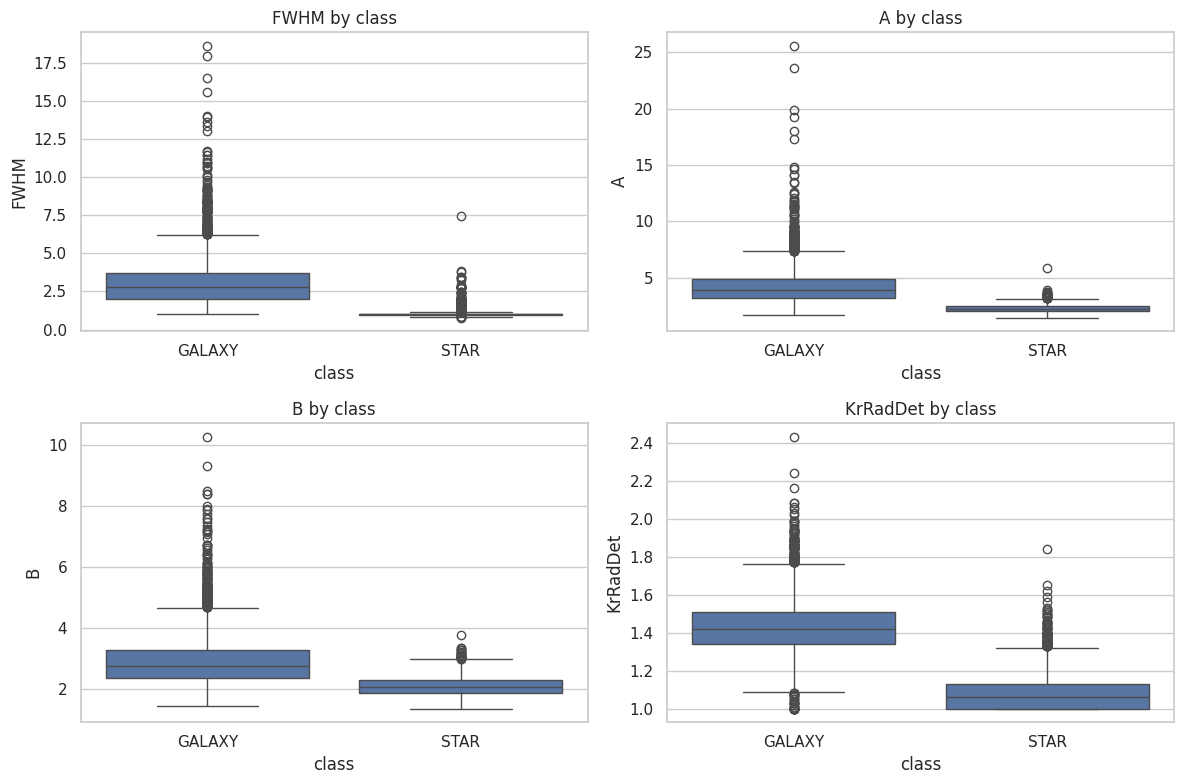

In [44]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for ax, feature in zip(axes.flatten(), features_hist):
    sns.boxplot(data=data, x="class", y=feature, ax=ax)
    ax.set_title(f"{feature} by class")

plt.tight_layout()
plt.show()

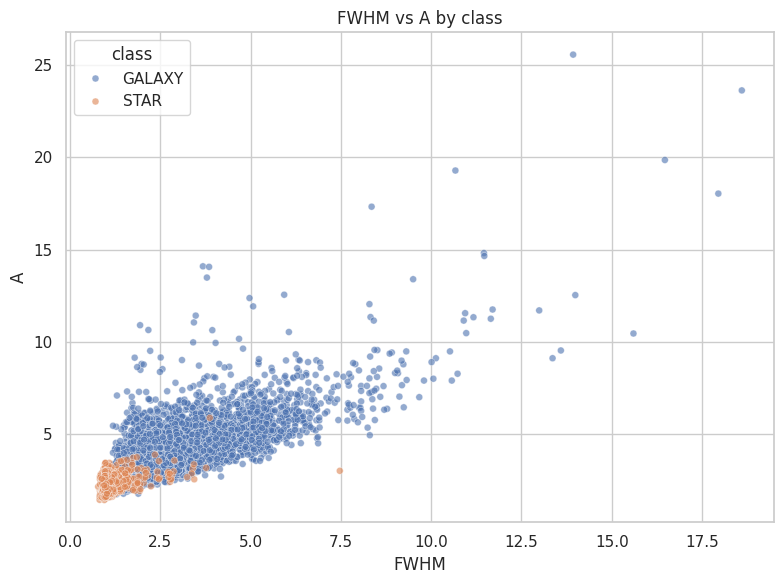

In [45]:
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=data,
    x="FWHM",
    y="A",
    hue="class",
    alpha=0.6,
    s=25
)

plt.title("FWHM vs A by class")
plt.xlabel("FWHM")
plt.ylabel("A")
plt.legend(title="class")
plt.tight_layout()
plt.show()

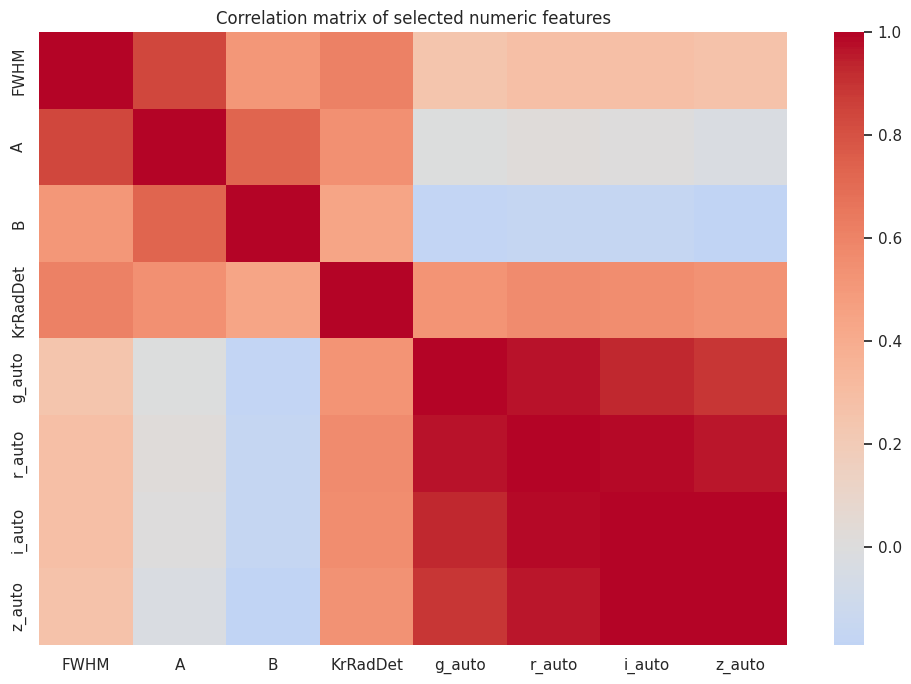

In [46]:
heatmap_cols = ["FWHM", "A", "B", "KrRadDet", "g_auto", "r_auto", "i_auto", "z_auto"]

plt.figure(figsize=(10, 7))
correlation = data[heatmap_cols].corr()
sns.heatmap(correlation, cmap="coolwarm", center=0, annot=False)
plt.title("Correlation matrix of selected numeric features")
plt.tight_layout()
plt.show()

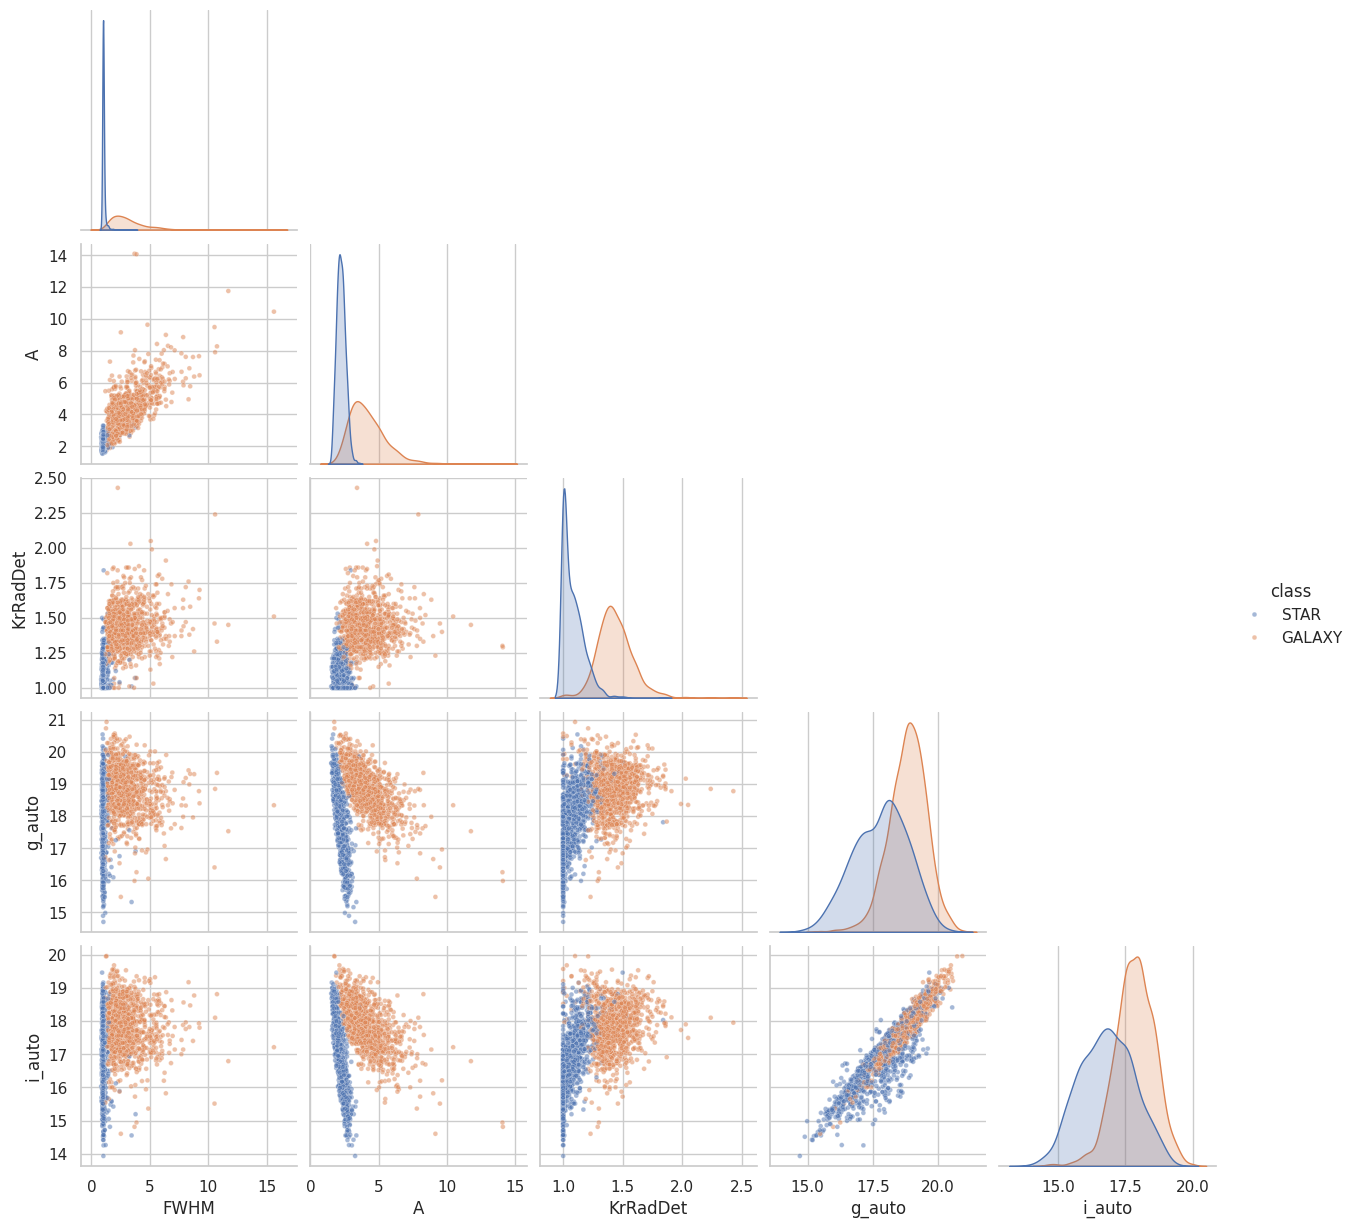

In [47]:
pairplot_cols = ["class", "FWHM", "A", "KrRadDet", "g_auto", "i_auto"]
pairplot_sample = data[pairplot_cols].sample(n=min(2000, len(data)), random_state=42)

sns.pairplot(pairplot_sample, hue="class", corner=True, plot_kws={"alpha": 0.5, "s": 12})
plt.show()

# 4) Key findings summary

In [53]:
top_effects = smd.dropna().iloc[:5]

print("Top 5 features separating STAR and GALAXY (standardized mean difference):")
print(top_effects.round(3))

print("\nInterpretation guide:")
print("- Positive value: higher mean in STAR")
print("- Negative value: higher mean in GALAXY")
print("- Larger absolute value: stronger class separation")

Top 5 features separating STAR and GALAXY (standardized mean difference):
KrRadDet   -2.885
FWHM       -1.913
A          -1.793
B          -1.338
r_auto     -1.220
dtype: float64

Interpretation guide:
- Positive value: higher mean in STAR
- Negative value: higher mean in GALAXY
- Larger absolute value: stronger class separation
